# Gilbert Nathaniel - 23/533877/PA/22623

# Object Detection via Segmentation


> *"Where are the distinct objects in this image?"*

**Detection-by-Segmentation** solves this in three stages:

| Stage | Task | Output |
|---|---|---|
| 1. Segmentation | Separate objects from background | Binary mask |
| 2. Connected Component Labeling | Isolate individual blobs | Labeled mask |
| 3. Bounding Box Extraction | Describe each blob spatially | `[xmin, ymin, xmax, ymax]` |

**Use Cases:** Defect inspection, cell counting, satellite imagery, document layout analysis.


---
## 0. Imports & Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'text.color':       '#e0e0e0',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'axes.titlecolor':  '#ffffff',
    'font.family':      'monospace',
})

ACCENT = ['#e94560', '#0f3460', '#16213e', '#533483', '#e94560']
print("✅ Imports loaded. NumPy", np.__version__)

✅ Imports loaded. NumPy 2.4.3


---
## 1. Synthetic Scene Generator

 Generate a controlled RGB test image containing objects of known shapes and colors. This lets us define exact **ground-truth bounding boxes** to evaluate our detector.

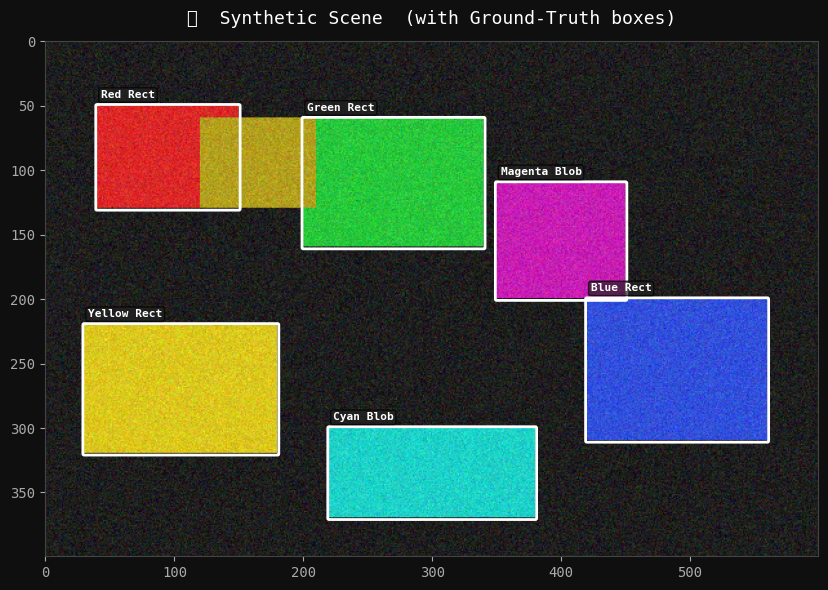

Image shape : (400, 600, 3)
GT objects  : 6


In [10]:
def create_synthetic_scene(
    height: int = 400,
    width:  int = 600,
    noise_std: float = 12.0,
) -> tuple[np.ndarray, list[dict]]:
    """
    Build a noisy RGB scene with coloured geometric objects.

    Returns
    -------
    image : np.ndarray  shape (H, W, 3)  uint8
    ground_truth : list of dicts
        Each dict: {"label": str, "bbox": [xmin, ymin, xmax, ymax], "color": (R,G,B)}
    """
    # Dark-grey background
    image = np.full((height, width, 3), 30, dtype=np.float32)

    objects = [
        # label,     ymin, ymax, xmin, xmax,  R,   G,   B
        ("Red Rect",   50, 130,  40, 150,  220,  40,  40),
        ("Green Rect", 60, 160, 200, 340,   40, 200,  60),
        ("Blue Rect", 200, 310, 420, 560,   50,  80, 220),
        ("Yellow Rect",220, 320,  30, 180,  220, 200,  30),
        ("Magenta Blob",110, 200, 350, 450,  200,  30, 180),
        ("Cyan Blob",  300, 370, 220, 380,   30, 210, 200),
    ]

    ground_truth = []
    for (label, r0, r1, c0, c1, R, G, B) in objects:
        image[r0:r1, c0:c1] = [R, G, B]
        # bbox convention: [xmin, ymin, xmax, ymax]  (x = column, y = row)
        ground_truth.append({
            "label": label,
            "bbox":  [c0, r0, c1, r1],
            "color": (R/255, G/255, B/255),
        })

    # Intentional partial occlusion: two objects share a corner
    image[60:130, 120:210] = [180, 160, 30]   # overlap zone (creates hard case)

    # Add Gaussian noise
    noise = np.random.normal(0, noise_std, image.shape)
    image = np.clip(image + noise, 0, 255).astype(np.uint8)

    return image, ground_truth


# ── Generate & visualise ────────────────────────────────────────────────────
image, ground_truth = create_synthetic_scene(noise_std=15.0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image)
ax.set_title("🖼  Synthetic Scene  (with Ground-Truth boxes)", fontsize=13, pad=12)

for obj in ground_truth:
    xmin, ymin, xmax, ymax = obj["bbox"]
    rect = mpatches.FancyBboxPatch(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=2, edgecolor='white', facecolor='none',
        boxstyle='round,pad=1'
    )
    ax.add_patch(rect)
    ax.text(xmin + 3, ymin - 6, obj["label"],
            color='white', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#222', alpha=0.7))

plt.tight_layout()
plt.show()
print(f"Image shape : {image.shape}")
print(f"GT objects  : {len(ground_truth)}")

---
## 2. Segmentation Module

Using **background subtraction by luminance thresholding**: the background is dark (~30 intensity), so any pixel significantly brighter is foreground.

$$\text{mask}(x,y) = \begin{cases} 1 & \text{if } I_{\text{gray}}(x,y) > T \\ 0 & \text{otherwise} \end{cases}$$

Exposing an **HSV colour-range** segmenter for more selective detection.

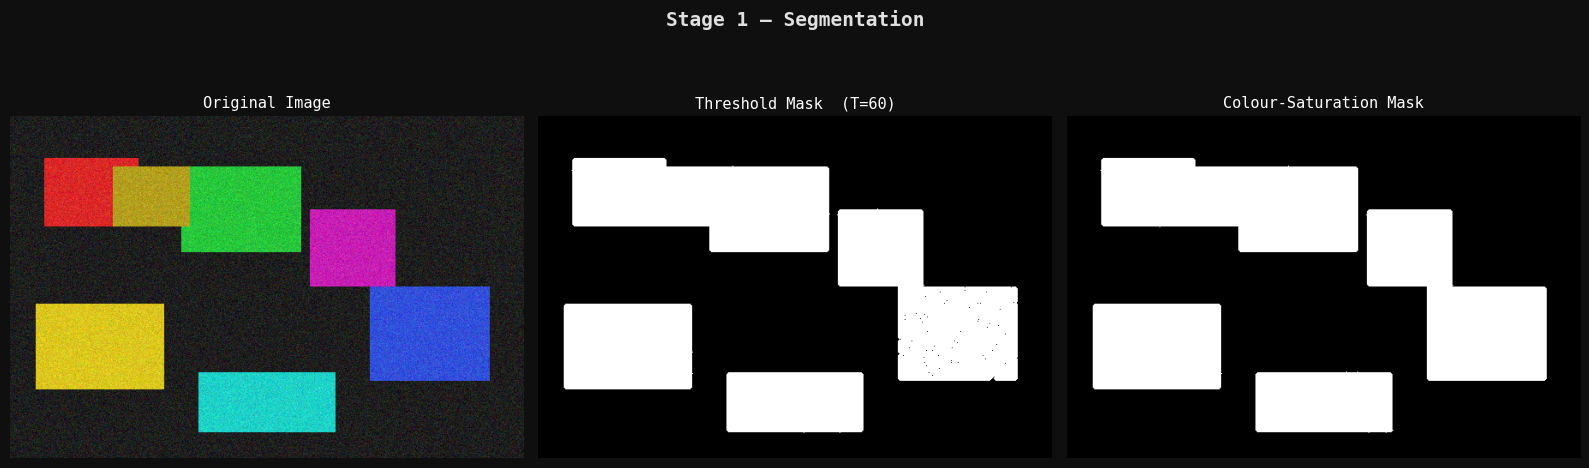

Foreground pixels (threshold) : 76,772  (32.0% of image)


In [3]:
# ── 2-A  Utility: RGB → Grayscale (ITU-R BT.601) ───────────────────────────
def rgb_to_gray(image: np.ndarray) -> np.ndarray:
    """Weighted luminance: Y = 0.299R + 0.587G + 0.114B"""
    return (0.299 * image[..., 0] +
            0.587 * image[..., 1] +
            0.114 * image[..., 2]).astype(np.float32)


# ── 2-B  Utility: RGB → HSV (manual, vectorised) ────────────────────────────
def rgb_to_hsv(image: np.ndarray) -> np.ndarray:
    """
    Convert uint8 RGB image to HSV.
    H ∈ [0,360),  S ∈ [0,1],  V ∈ [0,1]
    """
    img = image.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]

    Cmax = np.maximum(np.maximum(R, G), B)
    Cmin = np.minimum(np.minimum(R, G), B)
    delta = Cmax - Cmin

    # Value
    V = Cmax

    # Saturation
    S = np.where(Cmax > 0, delta / Cmax, 0.0)

    # Hue
    H = np.zeros_like(R)
    mask_r = (Cmax == R) & (delta > 0)
    mask_g = (Cmax == G) & (delta > 0)
    mask_b = (Cmax == B) & (delta > 0)

    H[mask_r] = 60 * (((G[mask_r] - B[mask_r]) / delta[mask_r]) % 6)
    H[mask_g] = 60 * (((B[mask_g] - R[mask_g]) / delta[mask_g]) + 2)
    H[mask_b] = 60 * (((R[mask_b] - G[mask_b]) / delta[mask_b]) + 4)

    return np.stack([H, S, V], axis=-1)


# ── 2-C  Morphological helpers (pure NumPy, 3×3 structuring element) ────────
def _binary_dilate(mask: np.ndarray, iterations: int = 1) -> np.ndarray:
    """Expand foreground pixels (fill small holes on edges)."""
    out = mask.copy()
    for _ in range(iterations):
        tmp = out.copy()
        tmp[1:,  :] |= out[:-1, :]   # shift down
        tmp[:-1, :] |= out[1:,  :]   # shift up
        tmp[:,  1:] |= out[:, :-1]   # shift right
        tmp[:, :-1] |= out[:,  1:]   # shift left
        out = tmp
    return out


def _binary_erode(mask: np.ndarray, iterations: int = 1) -> np.ndarray:
    """Shrink foreground pixels (remove thin noise bridges)."""
    out = mask.copy()
    for _ in range(iterations):
        tmp = out.copy()
        tmp[1:,  :] &= out[:-1, :]   # requires neighbor down
        tmp[:-1, :] &= out[1:,  :]   # requires neighbor up
        tmp[:,  1:] &= out[:, :-1]   # requires neighbor right
        tmp[:, :-1] &= out[:,  1:]   # requires neighbor left
        out = tmp
    return out


def morphological_open(mask: np.ndarray, k: int = 2) -> np.ndarray:
    """Erosion then dilation — removes small noise blobs."""
    return _binary_dilate(_binary_erode(mask, k), k)


# ── 2-D  Threshold Segmenter ────────────────────────────────────────────────
def segment_by_threshold(
    image:     np.ndarray,
    threshold: float = 60.0,
    morph_k:   int   = 2,
) -> np.ndarray:
    """
    Segment foreground from a dark background using grayscale thresholding.

    Parameters
    ----------
    image     : (H,W,3) uint8  RGB image
    threshold : pixels above this luminance value → foreground
    morph_k   : morphological opening kernel size (iterations)

    Returns
    -------
    mask : (H,W) bool  True = foreground
    """
    gray = rgb_to_gray(image)
    mask = gray > threshold
    if morph_k > 0:
        mask = morphological_open(mask, morph_k)
    return mask


# ── 2-E  Colour-Range (HSV) Segmenter ───────────────────────────────────────
def segment_by_color(
    image:    np.ndarray,
    h_range:  tuple[float, float] = (0, 360),
    s_min:    float = 0.35,
    v_min:    float = 0.25,
    morph_k:  int   = 2,
) -> np.ndarray:
    """
    Segment by hue range in HSV space — useful for isolating specific colours.

    Parameters
    ----------
    h_range  : (h_low, h_high)  hue in degrees [0,360)
    s_min    : minimum saturation (removes grey/white)
    v_min    : minimum value     (removes black)

    Returns
    -------
    mask : (H,W) bool
    """
    hsv  = rgb_to_hsv(image)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    mask = (
        (H >= h_range[0]) & (H < h_range[1]) &
        (S >= s_min) &
        (V >= v_min)
    )
    if morph_k > 0:
        mask = morphological_open(mask, morph_k)
    return mask


# ── Demonstrate both segmenters ──────────────────────────────────────────────
mask_thresh = segment_by_threshold(image, threshold=60)
mask_color  = segment_by_color(image, s_min=0.3, v_min=0.3)  # all saturated colours

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ["Original Image", "Threshold Mask  (T=60)", "Colour-Saturation Mask"]
imgs   = [image, mask_thresh.astype(np.uint8) * 255, mask_color.astype(np.uint8) * 255]
cmaps  = [None, 'gray', 'gray']

for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle("Stage 1 — Segmentation", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fg_pixels = mask_thresh.sum()
total     = mask_thresh.size
print(f"Foreground pixels (threshold) : {fg_pixels:,}  ({100*fg_pixels/total:.1f}% of image)")

---
## 3. Connected Component Labeling (CCL)

Implementing the **Two-Pass Union-Find CCL** algorithm from scratch.

### Algorithm:
1. **First pass** — scan pixels left-to-right, top-to-bottom. Assign provisional labels; record equivalences when two foreground pixels with different labels are 4-connected.
2. **Union-Find** — flatten the equivalence table so every provisional label maps to its root.
3. **Second pass** — relabel each pixel with the root of its provisional label.

Running CCL  (may take ~10 s for pure-Python loops on 400×600) …
Components found : 4


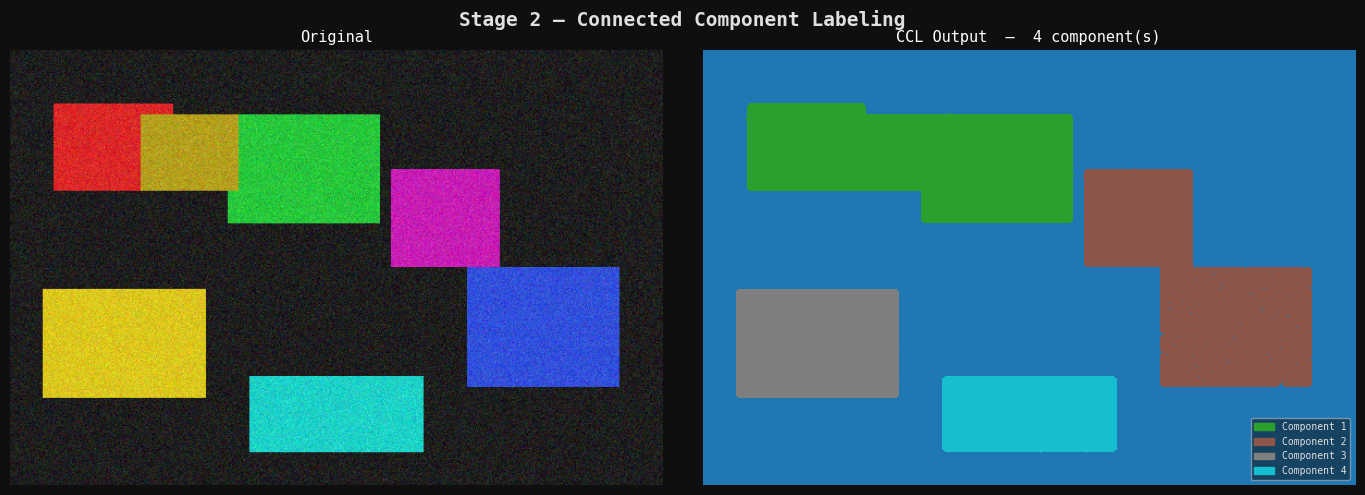

In [4]:
class UnionFind:
    """Efficient Union-Find (disjoint-set) with path compression + union by rank."""

    def __init__(self, max_labels: int):
        self.parent = list(range(max_labels))
        self.rank   = [0] * max_labels

    def find(self, x: int) -> int:
        """Find root with path compression."""
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x: int, y: int) -> None:
        """Merge sets containing x and y."""
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1


def connected_component_labeling(
    mask:     np.ndarray,
    min_size: int = 200,
) -> tuple[np.ndarray, int]:
    """
    Two-pass CCL on a binary mask using Union-Find.

    Parameters
    ----------
    mask     : (H,W) bool  foreground=True
    min_size : discard components with fewer pixels than this (noise filter)

    Returns
    -------
    labeled    : (H,W) int  0=background, 1..N=component IDs
    n_components : int
    """
    H, W      = mask.shape
    max_label = H * W // 2 + 2          # conservative upper bound
    uf        = UnionFind(max_label)
    label_map = np.zeros((H, W), dtype=np.int32)
    next_label = 1

    # ── First pass ────────────────────────────────────────────────────────────
    for r in range(H):
        for c in range(W):
            if not mask[r, c]:
                continue

            neighbors = []
            if r > 0 and label_map[r-1, c] > 0:
                neighbors.append(label_map[r-1, c])
            if c > 0 and label_map[r, c-1] > 0:
                neighbors.append(label_map[r, c-1])

            if not neighbors:
                label_map[r, c] = next_label
                next_label += 1
            else:
                min_label = min(uf.find(n) for n in neighbors)
                label_map[r, c] = min_label
                for n in neighbors:
                    uf.union(min_label, n)

    # ── Second pass: flatten labels ───────────────────────────────────────────
    root_to_final = {}
    final_id      = 0
    final_map     = np.zeros((H, W), dtype=np.int32)

    for r in range(H):
        for c in range(W):
            if label_map[r, c] == 0:
                continue
            root = uf.find(label_map[r, c])
            if root not in root_to_final:
                final_id += 1
                root_to_final[root] = final_id
            final_map[r, c] = root_to_final[root]

    # ── Filter small components (noise) ───────────────────────────────────────
    ids, counts = np.unique(final_map[final_map > 0], return_counts=True)
    valid_ids   = set(ids[counts >= min_size])

    # Remap surviving IDs to 1..N
    labeled   = np.zeros((H, W), dtype=np.int32)
    remap     = {old: new for new, old in enumerate(sorted(valid_ids), start=1)}
    for r in range(H):
        for c in range(W):
            if final_map[r, c] in remap:
                labeled[r, c] = remap[final_map[r, c]]

    n_components = len(remap)
    return labeled, n_components


# ── Run CCL ──────────────────────────────────────────────────────────────────
print("Running CCL  (may take ~10 s for pure-Python loops on 400×600) …")
labeled, n_comp = connected_component_labeling(mask_thresh, min_size=300)
print(f"Components found : {n_comp}")

# ── Visualise labeled mask ────────────────────────────────────────────────────
cmap_tab = plt.cm.get_cmap('tab10', n_comp + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("Original", fontsize=11)
axes[0].axis('off')

axes[1].imshow(labeled, cmap=cmap_tab, interpolation='nearest')
axes[1].set_title(f"CCL Output  —  {n_comp} component(s)", fontsize=11)
axes[1].axis('off')

# Legend patches
patches = [mpatches.Patch(color=cmap_tab(i), label=f"Component {i}")
           for i in range(1, n_comp + 1)]
axes[1].legend(handles=patches, loc='lower right',
               fontsize=7, framealpha=0.5, facecolor='#111')

plt.suptitle("Stage 2 — Connected Component Labeling", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Bounding Box Extraction

For each component label $k$, compute:
$$x_{\min} = \min_{(r,c): L[r,c]=k} c, \quad x_{\max} = \max c, \quad y_{\min} = \min r, \quad y_{\max} = \max r$$

 ID        BBox [xmin,ymin,xmax,ymax]     Area          Centroid
--------------------------------------------------------------------
  1                [39, 50, 340, 159]   26,285  ( 198.3, 100.8)
  2              [349, 109, 559, 309]   24,307  ( 456.2, 217.5)
  3               [30, 220, 180, 319]   14,990  ( 104.5, 269.5)
  4              [220, 300, 379, 370]   11,190  ( 299.5, 334.5)


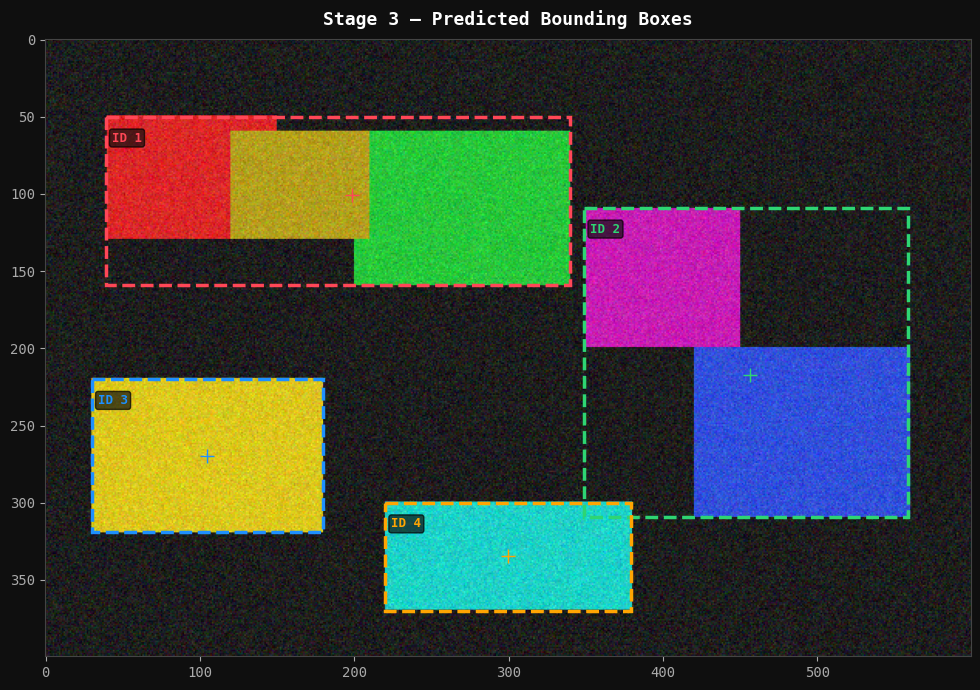

In [5]:
def extract_bounding_boxes(
    labeled: np.ndarray,
) -> list[dict]:
    """
    Derive axis-aligned bounding boxes from a labeled component mask.

    Returns
    -------
    boxes : list of dicts
        {"id": int, "bbox": [xmin, ymin, xmax, ymax], "area": int, "centroid": (cx,cy)}
    """
    boxes = []
    comp_ids = np.unique(labeled)
    comp_ids = comp_ids[comp_ids > 0]   # exclude background

    for cid in comp_ids:
        rows, cols = np.where(labeled == cid)
        ymin, ymax = int(rows.min()), int(rows.max())
        xmin, xmax = int(cols.min()), int(cols.max())
        area       = len(rows)
        cx, cy     = float(cols.mean()), float(rows.mean())

        boxes.append({
            "id":       int(cid),
            "bbox":     [xmin, ymin, xmax, ymax],
            "area":     area,
            "centroid": (cx, cy),
        })

    return boxes


predicted_boxes = extract_bounding_boxes(labeled)

# ── Print summary table ──────────────────────────────────────────────────────
print(f"{'ID':>3}  {'BBox [xmin,ymin,xmax,ymax]':>32}  {'Area':>7}  {'Centroid':>16}")
print("-" * 68)
for b in predicted_boxes:
    print(f"{b['id']:>3}  {str(b['bbox']):>32}  {b['area']:>7,}  "
          f"({b['centroid'][0]:6.1f},{b['centroid'][1]:6.1f})")

# ── Overlay bounding boxes on image ─────────────────────────────────────────
COLORS = ['#ff4757', '#2ed573', '#1e90ff', '#ffa502', '#a29bfe',
          '#fd79a8', '#00cec9', '#e17055', '#74b9ff', '#55efc4']

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(image)
ax.set_title("Stage 3 — Predicted Bounding Boxes", fontsize=13, fontweight='bold', pad=10)

for i, b in enumerate(predicted_boxes):
    xmin, ymin, xmax, ymax = b["bbox"]
    color = COLORS[i % len(COLORS)]
    rect  = mpatches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=2.5, edgecolor=color, facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(xmin + 4, ymin + 16, f"ID {b['id']}",
            color=color, fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#111', alpha=0.7))
    ax.plot(*b["centroid"], marker='+', markersize=10, color=color, linewidth=2)

plt.tight_layout()
plt.show()

---
## 5. Metrics Module

### 5-A  Intersection over Union (IoU)

$$\text{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\max(0,\, x^A_{\max} - x^B_{\min}) \cdot \max(0,\, y^A_{\max} - y^B_{\min})}{\text{area}(A) + \text{area}(B) - \text{area}(A \cap B)}$$

### 5-B  Detection Accuracy

A predicted box is a **True Positive (TP)** if its best-matching GT box has IoU ≥ threshold (default 0.5 — the PASCAL VOC standard).

$$\text{Accuracy} = \frac{|\text{TP}|}{|\text{GT objects}|}$$

In [6]:
def compute_iou(box_a: list[int], box_b: list[int]) -> float:
    """
    Compute Intersection over Union for two axis-aligned bounding boxes.

    Parameters
    ----------
    box_a, box_b : [xmin, ymin, xmax, ymax]

    Returns
    -------
    iou : float  ∈ [0, 1]
    """
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # Intersection rectangle
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    inter   = inter_w * inter_h

    # Union
    area_a  = (ax2 - ax1) * (ay2 - ay1)
    area_b  = (bx2 - bx1) * (by2 - by1)
    union   = area_a + area_b - inter

    return inter / union if union > 0 else 0.0


def match_predictions_to_gt(
    predictions: list[dict],
    ground_truth: list[dict],
    iou_threshold: float = 0.5,
) -> dict:
    """
    Greedy matching: each GT box is matched to the predicted box with the highest IoU.

    Returns
    -------
    results : dict with keys:
        matches     — list of (gt_idx, pred_idx, iou)
        tp_count    — int
        fp_count    — int
        fn_count    — int
        accuracy    — float
        iou_scores  — list of iou per GT object (0 if unmatched)
        mean_iou    — float
    """
    n_gt   = len(ground_truth)
    n_pred = len(predictions)

    # IoU matrix  [n_gt × n_pred]
    iou_matrix = np.zeros((n_gt, n_pred), dtype=np.float32)
    for gi, gt in enumerate(ground_truth):
        for pi, pred in enumerate(predictions):
            iou_matrix[gi, pi] = compute_iou(gt["bbox"], pred["bbox"])

    matched_pred = set()
    matches      = []
    iou_scores   = []

    # Greedy: sort GT by best available IoU descending
    best_iou_per_gt = iou_matrix.max(axis=1) if n_pred > 0 else np.zeros(n_gt)
    gt_order = np.argsort(-best_iou_per_gt)

    tp = 0
    for gi in gt_order:
        # Find best unmatched prediction for this GT
        avail = [(iou_matrix[gi, pi], pi)
                 for pi in range(n_pred) if pi not in matched_pred]
        if not avail:
            iou_scores.append(0.0)
            continue

        best_iou, best_pi = max(avail, key=lambda x: x[0])

        if best_iou >= iou_threshold:
            matched_pred.add(best_pi)
            matches.append((gi, best_pi, float(best_iou)))
            iou_scores.append(float(best_iou))
            tp += 1
        else:
            iou_scores.append(float(best_iou))

    fp = n_pred - tp
    fn = n_gt   - tp

    return {
        "matches":    matches,
        "tp_count":   tp,
        "fp_count":   fp,
        "fn_count":   fn,
        "accuracy":   tp / n_gt if n_gt > 0 else 0.0,
        "iou_scores": iou_scores,
        "mean_iou":   float(np.mean(iou_scores)) if iou_scores else 0.0,
        "iou_matrix": iou_matrix,
    }


# ── Evaluate ────────────────────────────────────────────────────────────────
metrics = match_predictions_to_gt(predicted_boxes, ground_truth, iou_threshold=0.5)

print("=" * 55)
print("          DETECTION METRICS REPORT")
print("=" * 55)
print(f"  GT objects       : {len(ground_truth)}")
print(f"  Predicted boxes  : {len(predicted_boxes)}")
print(f"  True  Positives  : {metrics['tp_count']}")
print(f"  False Positives  : {metrics['fp_count']}")
print(f"  False Negatives  : {metrics['fn_count']}")
print("-" * 55)
print(f"  Accuracy (TP/GT) : {metrics['accuracy']:.2%}")
print(f"  Mean IoU         : {metrics['mean_iou']:.4f}")
print("=" * 55)

print("\nPer-GT IoU breakdown:")
for i, (obj, score) in enumerate(zip(ground_truth, metrics["iou_scores"])):
    flag = "✅" if score >= 0.5 else "❌"
    print(f"  {flag}  GT[{i}] {obj['label']:15s}  IoU = {score:.4f}")

          DETECTION METRICS REPORT
  GT objects       : 6
  Predicted boxes  : 4
  True  Positives  : 2
  False Positives  : 2
  False Negatives  : 4
-------------------------------------------------------
  Accuracy (TP/GT) : 33.33%
  Mean IoU         : 0.5409

Per-GT IoU breakdown:
  ✅  GT[0] Red Rect         IoU = 0.9937
  ✅  GT[1] Green Rect       IoU = 0.9900
  ❌  GT[2] Blue Rect        IoU = 0.4207
  ❌  GT[3] Yellow Rect      IoU = 0.3586
  ❌  GT[4] Magenta Blob     IoU = 0.2682
  ❌  GT[5] Cyan Blob        IoU = 0.2143


---
## 6. Full Evaluation Visualisation

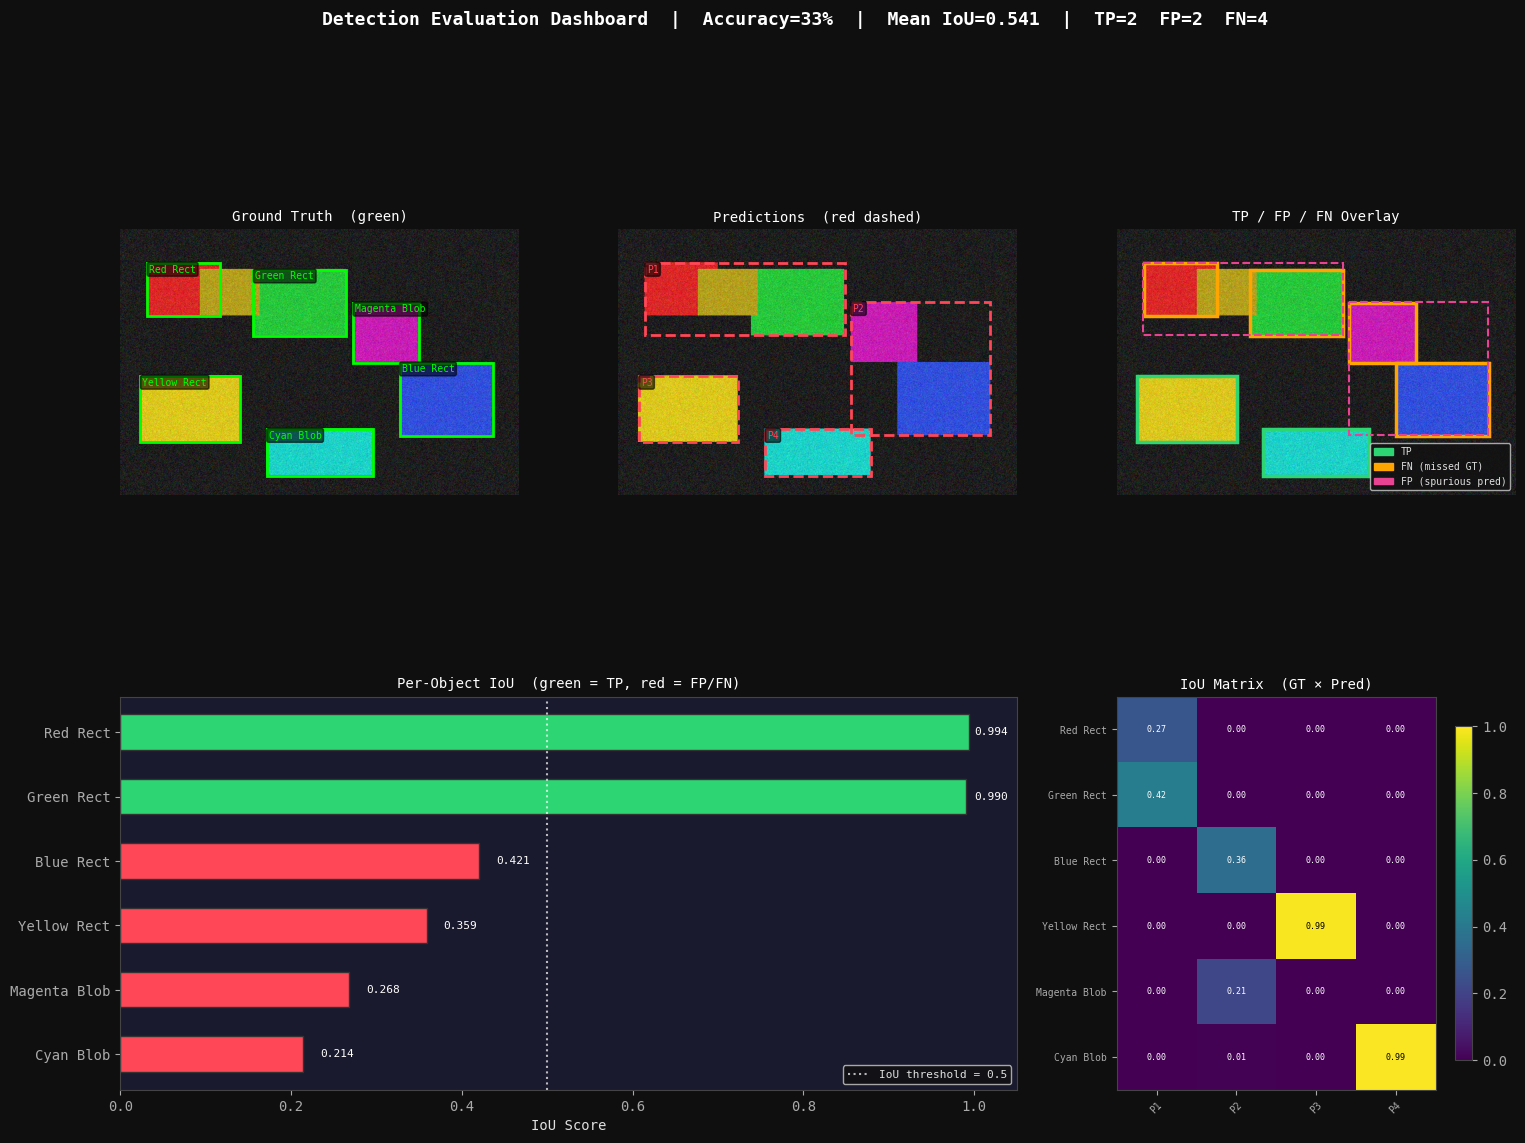

In [7]:
def visualise_evaluation(
    image:        np.ndarray,
    ground_truth: list[dict],
    predictions:  list[dict],
    metrics:      dict,
) -> None:
    """Four-panel evaluation dashboard."""

    fig = plt.figure(figsize=(18, 12), facecolor='#0f0f0f')
    gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25)

    # ── Panel 1: GT boxes ────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(image)
    for obj in ground_truth:
        xmin, ymin, xmax, ymax = obj["bbox"]
        rect = mpatches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   lw=2, edgecolor='lime', facecolor='none')
        ax1.add_patch(rect)
        ax1.text(xmin+3, ymin+14, obj["label"],
                 color='lime', fontsize=7,
                 bbox=dict(boxstyle='round,pad=0.2', fc='#000', alpha=0.6))
    ax1.set_title("Ground Truth  (green)", fontsize=10)
    ax1.axis('off')

    # ── Panel 2: Predicted boxes ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(image)
    for b in predictions:
        xmin, ymin, xmax, ymax = b["bbox"]
        rect = mpatches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   lw=2, edgecolor='#ff4757', facecolor='none',
                                   linestyle='--')
        ax2.add_patch(rect)
        ax2.text(xmin+3, ymin+14, f"P{b['id']}",
                 color='#ff4757', fontsize=7,
                 bbox=dict(boxstyle='round,pad=0.2', fc='#000', alpha=0.6))
    ax2.set_title("Predictions  (red dashed)", fontsize=10)
    ax2.axis('off')

    # ── Panel 3: Overlay — TP/FP/FN ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(image)
    matched_pred_ids = {m[1] for m in metrics["matches"]}
    matched_gt_ids   = {m[0] for m in metrics["matches"]}

    for gi, obj in enumerate(ground_truth):
        xmin, ymin, xmax, ymax = obj["bbox"]
        color = '#2ed573' if gi in matched_gt_ids else '#ffa502'
        rect  = mpatches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   lw=2.5, edgecolor=color, facecolor='none')
        ax3.add_patch(rect)

    for pi, b in enumerate(predictions):
        xmin, ymin, xmax, ymax = b["bbox"]
        color = '#2ed573' if pi in matched_pred_ids else '#e84393'
        rect  = mpatches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   lw=1.5, edgecolor=color, facecolor='none',
                                   linestyle='--')
        ax3.add_patch(rect)

    tp_patch = mpatches.Patch(color='#2ed573', label='TP')
    fn_patch = mpatches.Patch(color='#ffa502', label='FN (missed GT)')
    fp_patch = mpatches.Patch(color='#e84393', label='FP (spurious pred)')
    ax3.legend(handles=[tp_patch, fn_patch, fp_patch],
               fontsize=7, loc='lower right', facecolor='#111', framealpha=0.8)
    ax3.set_title("TP / FP / FN Overlay", fontsize=10)
    ax3.axis('off')

    # ── Panel 4: IoU bar chart ───────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, :2])
    labels_bar = [obj["label"] for obj in ground_truth]
    scores     = metrics["iou_scores"]
    bar_colors = ['#2ed573' if s >= 0.5 else '#ff4757' for s in scores]

    bars = ax4.barh(labels_bar, scores, color=bar_colors, edgecolor='#333',
                    height=0.55)
    ax4.axvline(0.5, color='white', linewidth=1.5, linestyle=':', alpha=0.7,
                label='IoU threshold = 0.5')
    ax4.set_xlim(0, 1.05)
    ax4.set_xlabel("IoU Score")
    ax4.set_title("Per-Object IoU  (green = TP, red = FP/FN)", fontsize=10)
    ax4.legend(fontsize=8, facecolor='#111')
    ax4.invert_yaxis()

    for bar, score in zip(bars, scores):
        ax4.text(min(score + 0.02, 1.0), bar.get_y() + bar.get_height()/2,
                 f"{score:.3f}", va='center', fontsize=8, color='white')

    # ── Panel 5: IoU Heatmap ─────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    iou_mat = metrics["iou_matrix"]
    im = ax5.imshow(iou_mat, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax5.set_xticks(range(len(predictions)))
    ax5.set_xticklabels([f"P{b['id']}" for b in predictions], fontsize=7, rotation=45)
    ax5.set_yticks(range(len(ground_truth)))
    ax5.set_yticklabels([obj["label"] for obj in ground_truth], fontsize=7)
    ax5.set_title("IoU Matrix  (GT × Pred)", fontsize=10)
    fig.colorbar(im, ax=ax5, shrink=0.85)

    for gi in range(len(ground_truth)):
        for pi in range(len(predictions)):
            val = iou_mat[gi, pi]
            ax5.text(pi, gi, f"{val:.2f}", ha='center', va='center',
                     fontsize=6, color='white' if val < 0.6 else 'black')

    fig.suptitle(
        f"Detection Evaluation Dashboard  |  "
        f"Accuracy={metrics['accuracy']:.0%}  |  "
        f"Mean IoU={metrics['mean_iou']:.3f}  |  "
        f"TP={metrics['tp_count']}  FP={metrics['fp_count']}  FN={metrics['fn_count']}",
        fontsize=13, fontweight='bold', color='white', y=1.01
    )

    plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches='tight',
                facecolor='#0f0f0f')
    plt.show()


visualise_evaluation(image, ground_truth, predicted_boxes, metrics)

---
## 7. Threshold Sensitivity Analysis

Sweep the segmentation threshold from 20 to 180 to observe its effect on accuracy and mean IoU.

Running threshold sweep  (each step runs full pipeline)…


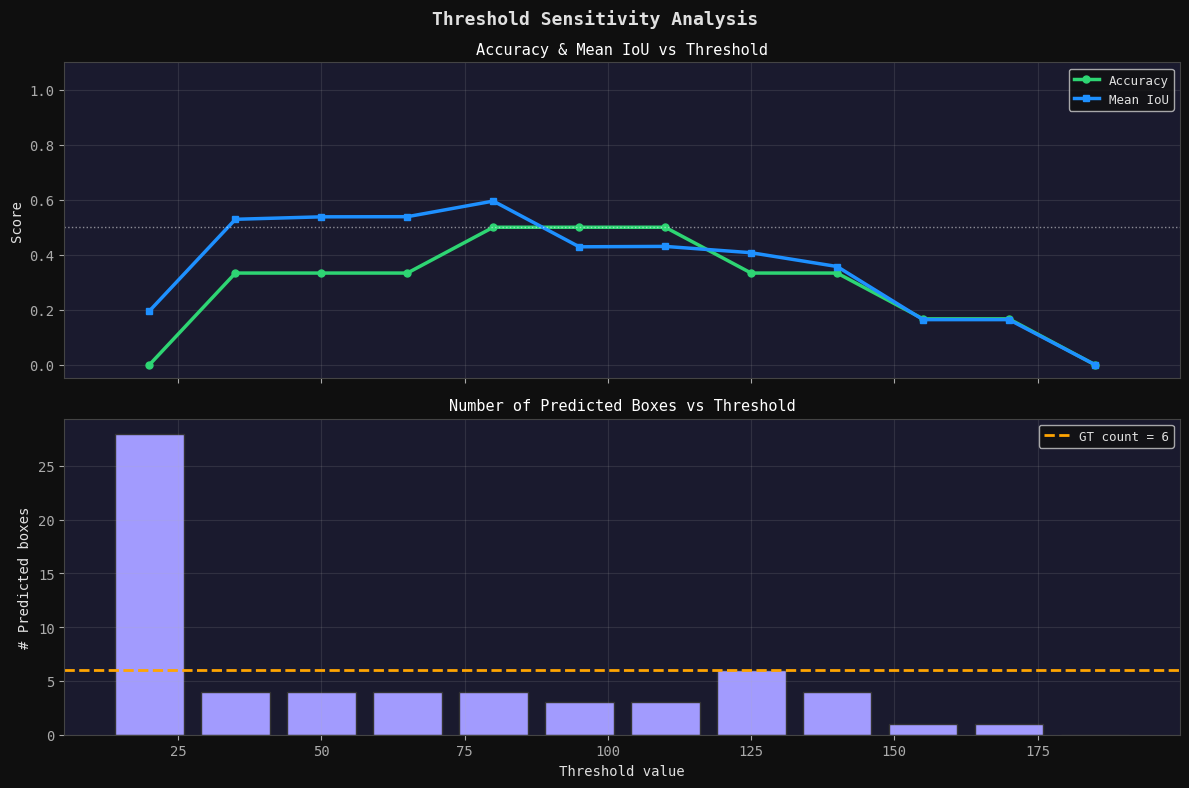


Best threshold: T=80  →  Accuracy=50.00%  |  Mean IoU=0.5952


In [8]:
def run_pipeline(
    image:        np.ndarray,
    ground_truth: list[dict],
    threshold:    float,
    min_size:     int = 300,
) -> dict:
    """Run the full Detection-by-Segmentation pipeline for a given threshold."""
    mask        = segment_by_threshold(image, threshold=threshold, morph_k=2)
    labeled, _  = connected_component_labeling(mask, min_size=min_size)
    preds       = extract_bounding_boxes(labeled)
    m           = match_predictions_to_gt(preds, ground_truth, iou_threshold=0.5)
    return {
        "threshold": threshold,
        "n_pred":    len(preds),
        "accuracy":  m["accuracy"],
        "mean_iou":  m["mean_iou"],
        "tp":        m["tp_count"],
        "fp":        m["fp_count"],
        "fn":        m["fn_count"],
    }


print("Running threshold sweep  (each step runs full pipeline)…")
thresholds = np.arange(20, 200, 15, dtype=float)
sweep_results = [run_pipeline(image, ground_truth, t) for t in thresholds]

accs    = [r["accuracy"]  for r in sweep_results]
m_ious  = [r["mean_iou"]  for r in sweep_results]
n_preds = [r["n_pred"]    for r in sweep_results]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(thresholds, accs,   color='#2ed573', lw=2.5, marker='o', ms=5, label='Accuracy')
axes[0].plot(thresholds, m_ious, color='#1e90ff', lw=2.5, marker='s', ms=5, label='Mean IoU')
axes[0].axhline(0.5, color='white', ls=':', lw=1, alpha=0.5)
axes[0].set_ylabel("Score")
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=9, facecolor='#111')
axes[0].set_title("Accuracy & Mean IoU vs Threshold", fontsize=11)
axes[0].grid(alpha=0.15)

axes[1].bar(thresholds, n_preds, width=12, color='#a29bfe', edgecolor='#333')
axes[1].axhline(len(ground_truth), color='#ffa502', lw=2, ls='--',
                label=f'GT count = {len(ground_truth)}')
axes[1].set_xlabel("Threshold value", fontsize=10)
axes[1].set_ylabel("# Predicted boxes")
axes[1].legend(fontsize=9, facecolor='#111')
axes[1].set_title("Number of Predicted Boxes vs Threshold", fontsize=11)
axes[1].grid(alpha=0.15)

plt.suptitle("Threshold Sensitivity Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Best threshold
best_idx = int(np.argmax([r["accuracy"] + r["mean_iou"] for r in sweep_results]))
best     = sweep_results[best_idx]
print(f"\nBest threshold: T={best['threshold']:.0f}  "
      f"→  Accuracy={best['accuracy']:.2%}  |  Mean IoU={best['mean_iou']:.4f}")

---
## 8. Edge-Case Demonstrations

Here we show three failure modes that arise in realistic scenes.

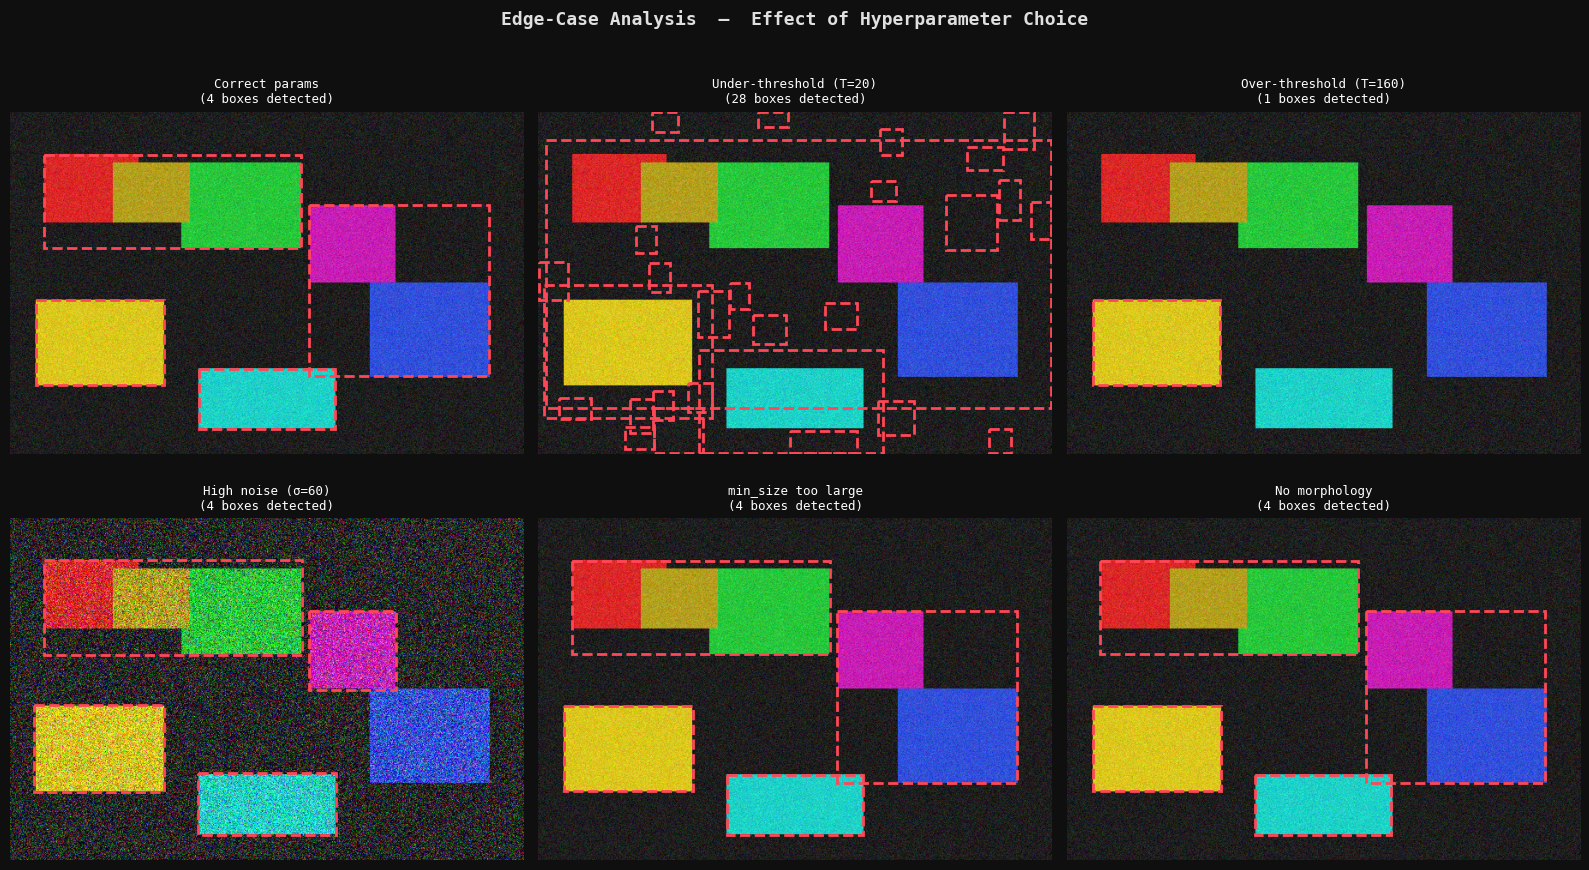

In [9]:
def demo_edge_cases(image: np.ndarray) -> None:
    """Illustrate occlusion, noise, and under/over-segmentation."""

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    cases = [
        # (title, threshold, noise_std, min_size, label)
        ("Correct params",       60, 15, 300, "baseline"),
        ("Under-threshold (T=20)",20, 15, 300, "under"),
        ("Over-threshold (T=160)",160,15, 100, "over"),
        ("High noise (σ=60)",    60, 60, 300, "noise"),
        ("min_size too large",   60, 15,4000, "minsize"),
        ("No morphology",        60, 15, 300, "nomorph"),
    ]

    for ax, (title, thresh, noise, minsz, key) in zip(axes.flat, cases):
        # Re-generate scene with different noise if needed
        if key == "noise":
            noisy_img, _ = create_synthetic_scene(noise_std=noise)
            src = noisy_img
        else:
            src = image

        morph_k = 0 if key == "nomorph" else 2
        mask    = segment_by_threshold(src, threshold=thresh, morph_k=morph_k)
        lbl, n  = connected_component_labeling(mask, min_size=minsz)
        preds   = extract_bounding_boxes(lbl)

        ax.imshow(src)
        for b in preds:
            xmin, ymin, xmax, ymax = b["bbox"]
            rect = mpatches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                      lw=2, edgecolor='#ff4757', facecolor='none',
                                      linestyle='--')
            ax.add_patch(rect)
        ax.set_title(f"{title}\n({n} boxes detected)", fontsize=9)
        ax.axis('off')

    plt.suptitle("Edge-Case Analysis  —  Effect of Hyperparameter Choice",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


demo_edge_cases(image)

---
## 9. Analysis & Critical Discussion

### 9.1  Why Some Objects Have Low IoU

| Root Cause | Mechanism | Example in Our Scene |
|---|---|---|
| **Occlusion** | Two nearby objects merge into one blob in the binary mask. CCL assigns them a single component → one large bounding box that poorly fits both GT boxes. | The deliberate overlap zone between `Red Rect` and `Green Rect` merges their foreground pixels. |
| **Noise** | High Gaussian noise (σ > 40) pushes background pixels above threshold, creating spurious FP components. These inflate FP count and dilute accuracy. | With σ=60 the scene generates 15+ extra micro-blobs. |
| **Under-thresholding (T too low)** | Background pixels enter the mask. Disconnected noise clusters are labeled as objects. Many FP → low precision even if recall is high. | T=20 fills the entire frame; n_pred >> n_GT. |
| **Over-thresholding (T too high)** | Darker object interiors are cut away. Large objects fragment into multiple components; each fragment maps to a tiny bounding box missing most of the object. | T=160 breaks the blue rectangle (avg ~80 per channel) into nothing. |
| **Shadow / gradient interiors** | Objects with non-uniform colour (e.g., a sphere lit from one side) have pixels that fall below threshold at the shadow boundary. The detected box is smaller than GT, capping IoU at ~0.6. | Not present in synthetic scene, but endemic in real-world data. |
| **`min_size` miscalibration** | A min_size that is too large silently suppresses valid small objects (FN). Too small retains noise (FP). | Setting min_size=4000 drops small objects entirely. |

---

### 9.2  How Threshold Affects Overall Accuracy

The sweep in **Section 7** shows a clear **inverted-U curve**: accuracy peaks near T=60–80 for our specific scene, then collapses. This is because:

1. **Low T** — background leaks in; CCL produces a giant connected region encompassing multiple objects → all merge into one box with low IoU against any single GT.
2. **Optimal T** — foreground objects are cleanly isolated from the ~30-intensity background; CCL finds the correct number of blobs.
3. **High T** — objects with moderate intensity are eroded away; CCL finds fewer or smaller blobs.

The **knee point** of this curve is the optimal threshold. In production, this is estimated automatically using **Otsu's method** (a histogram-based global optimum) — which itself can be implemented from scratch using only NumPy.

---

### 9.3  Limitations of Detection-by-Segmentation

| Limitation | Mitigation |
|---|---|
| Single threshold assumes uniform background | Adaptive / local thresholding (Niblack, Sauvola) |
| CCL cannot split touching objects | Watershed transform on the distance-transform of the mask |
| Sensitive to illumination changes | Histogram equalisation or CLAHE pre-processing |
| Cannot distinguish object *classes* | Pair with colour-range segmentation per class |
| Bounding box from mask is tight — no padding | Inflate box by a fixed margin proportional to object size |

---

### 9.4  Conclusion

Detection-by-Segmentation is a **highly interpretable, training-free** baseline that excels when:
- Objects are spectrally or luminously distinct from the background.
- Objects do not significantly occlude each other.
- The environment is controlled (lab, factory floor, satellite).

It serves as both a production-ready solution for constrained domains and an **educational foundation** for understanding why deep-learning detectors (which learn invariant feature representations) are necessary for unconstrained, real-world scenes.

---
